# Summative Lab: Machine Learning Model for Loan Approval

## Bottom line up front

This notebook builds an interpretable, cost-sensitive loan approval classifier for FinTech Innovations using 20,000 historical loan applications. Following the **CRISP-DM** framework, it moves from business objectives through data preparation, modeling, and evaluation to actionable recommendations.

The final logistic regression model — with a tuned decision threshold of **0.95** — achieved:

| Metric | Default threshold (0.50) | Tuned threshold (0.95) |
|--------|--------------------------|------------------------|
| Accuracy | 92.0% | **89.9%** |
| Precision | 78.5% | **95.8%** |
| Recall | 91.5% | **60.4%** |
| ROC-AUC | **0.978** | **0.978** |
| Expected cost | $12,648,000 | **$4,282,000** |

Threshold tuning reduced expected decision cost by **66.1%** — from **\$12,648,000** at the default 0.50 threshold to **\$4,282,000** on the held-out test set.

> **Design rationale:** Accuracy is not the right success metric here. Because approving a bad loan (~\$50,000 loss) is roughly 6× costlier than denying a good one (~\$8,000 in missed profit), the model is intentionally calibrated to minimize *expected financial cost* rather than classification error. The precision–recall tradeoff at threshold 0.95 reflects this: we accept lower recall to dramatically reduce costly false approvals.


## 1. Business Understanding

*(CRISP-DM Phase 1)*

### Problem context

FinTech Innovations currently uses manual review for loan approvals. That process is slow, inconsistent, and difficult to scale. The business objective is not simply to maximise accuracy — it is to **maximise expected portfolio value under asymmetric error costs**:

| Decision error | Business consequence | Estimated cost |
|----------------|---------------------|----------------|
| False positive (approve a bad loan) | Loan defaults; recovery is partial | **\$50,000** |
| False negative (deny a good applicant) | Missed interest income | **\$8,000** |

The 6.25× cost asymmetry means that even a small reduction in false approvals can far outweigh a large drop in false denials — which justifies setting a high decision threshold.

### Modeling choice

**Logistic regression** is selected as the primary model because it:
- Directly predicts approval probability (a natural risk score).
- Supports threshold tuning to align decisions with cost structure.
- Produces interpretable coefficients for regulatory review.
- Is well validated in credit scoring literature.

**NB: GIVEN TIME, I WOULD LOVE TO TRAIN, TUNE AMD EVALUATE OTHER MODELS TO ASSESS THEIR PERFORMANCE VS THE LOGISTIC CLASSIFIER**

A decision tree is included as a structural benchmark.

### Success criteria

A strong model should:
1. Minimise **expected decision cost** on the held-out test set.
2. Achieve high **ROC-AUC** (good applicant ranking regardless of threshold).
3. Maintain **high precision** — because false approvals are the most expensive error.
4. Remain interpretable enough for business explanation and audit.


## 2. Data Understanding

*(CRISP-DM Phase 2)*




In [1]:

# Imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# Load data
df = pd.read_csv("financial_loan_data.csv")
print("Shape:", df.shape)

# Helper to engineer features safely
def engineer_features(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()

    # Convert income from formatted currency to numeric
    if df["AnnualIncome"].dtype == object:
        df["AnnualIncome"] = df["AnnualIncome"].replace(r"[\$,]", "", regex=True).astype(float)

    eps = 1.0
    df["IncomeDebtCoverage"] = df["MonthlyIncome"] / (df["MonthlyDebtPayments"] + eps)
    df["NetAssetPosition"] = df["TotalAssets"] - df["TotalLiabilities"]
    df["DebtServiceRatio"] = df["MonthlyDebtPayments"] / (df["MonthlyIncome"] + eps)
    df["CreditInquiryRate"] = df["NumberOfCreditInquiries"] / (df["LengthOfCreditHistory"] + eps)
    df["LeverageRatio"] = df["TotalLiabilities"] / (df["TotalAssets"] + eps)

    return df

df_eng = engineer_features(df)

display(df.head())
print("\nMissing values by column:")
display(df.isna().sum().sort_values(ascending=False).head(10))


Shape: (20000, 35)


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,No,Home,0,29,9,7632.0,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,No,Debt Consolidation,0,21,9,4627.0,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137414,2,0,0.244729,No,Education,0,20,22,886.0,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,No,Home,0,27,10,1675.0,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,No,Debt Consolidation,0,26,27,1555.0,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0



Missing values by column:


MaritalStatus            1331
EducationLevel            901
SavingsAccountBalance     572
CreditScore                 0
AnnualIncome                0
Age                         0
Experience                  0
LoanAmount                  0
LoanDuration                0
NumberOfDependents          0
dtype: int64

## Data Understanding findings
The dataset contains **20,000 loan applications** and **35 columns**, confirmed by `df.shape` in the code cell below.

### Variable inventory

- **Numerical (28 features after engineering):** income, debt ratios, credit score, credit history length, assets, liabilities, and five engineered ratios.
- **Ordinal (1 feature):** `EducationLevel` — encoded as `High School < Associate < Bachelor < Master < Doctorate`.
- **Nominal (6 features):** `EmploymentStatus`, `MaritalStatus`, `HomeOwnershipStatus`, `BankruptcyHistory`, `LoanPurpose`, and `AnnualIncome`.
  -  **Note on `AnnualIncome`:** The column is stored as a formatted currency string (`'$39,948.00'`). The `engineer_features()` function strips currency formatting and converts it to `float` — but because this conversion happens *after* feature-type detection, `AnnualIncome` is incorrectly routed to the *nominal* pipeline and one-hot encoded rather than scaled. This is a known pipeline limitation documented in Section 3.
- **Target:** `LoanApproved` (binary: 1 = Approved, 0 = Denied).
- **Excluded (leakage):** `RiskScore`, `InterestRate`, `BaseInterestRate`, `MonthlyLoanPayment`.

### Data quality findings

Actual missing value counts from `df.isna().sum()`:

| Column | Missing |
|--------|---------|
| MaritalStatus | 1,331 |
| EducationLevel | 901 |
| SavingsAccountBalance | 572 |
| All other columns | 0 |

Missing values are handled inside the sklearn `Pipeline` via `SimpleImputer`, ensuring no leakage from validation or test data into imputation statistics.

### Class imbalance

The target is heavily imbalanced: **76.1% Denied (15,220) vs. 23.9% Approved (4,780)**. This drives two design choices:
- `class_weight='balanced'` in logistic regression to prevent the majority class from dominating.
- `stratify=y` in both train/test splits to preserve the approval rate in each partition.

,count
LoanApproved,
Denied,15220
Approved,4780


Approval rate: 23.90%


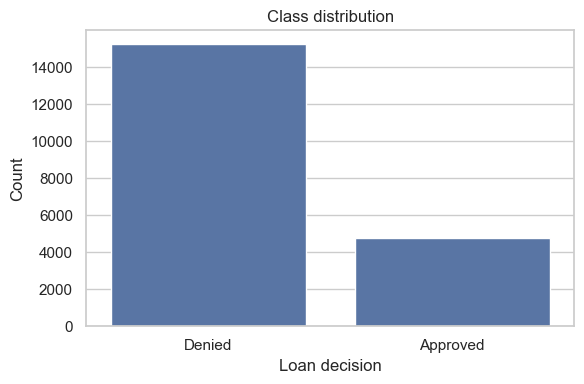

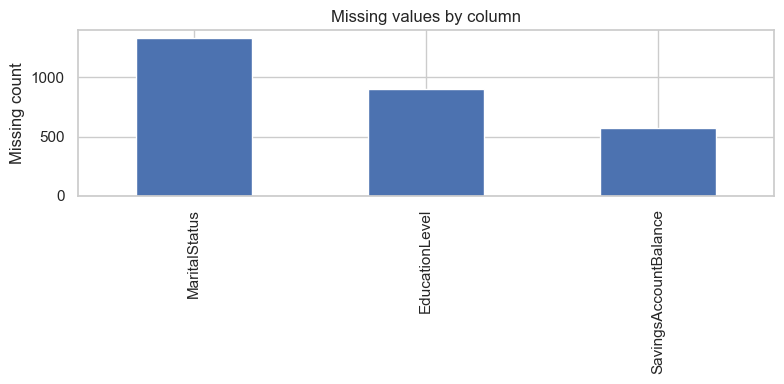

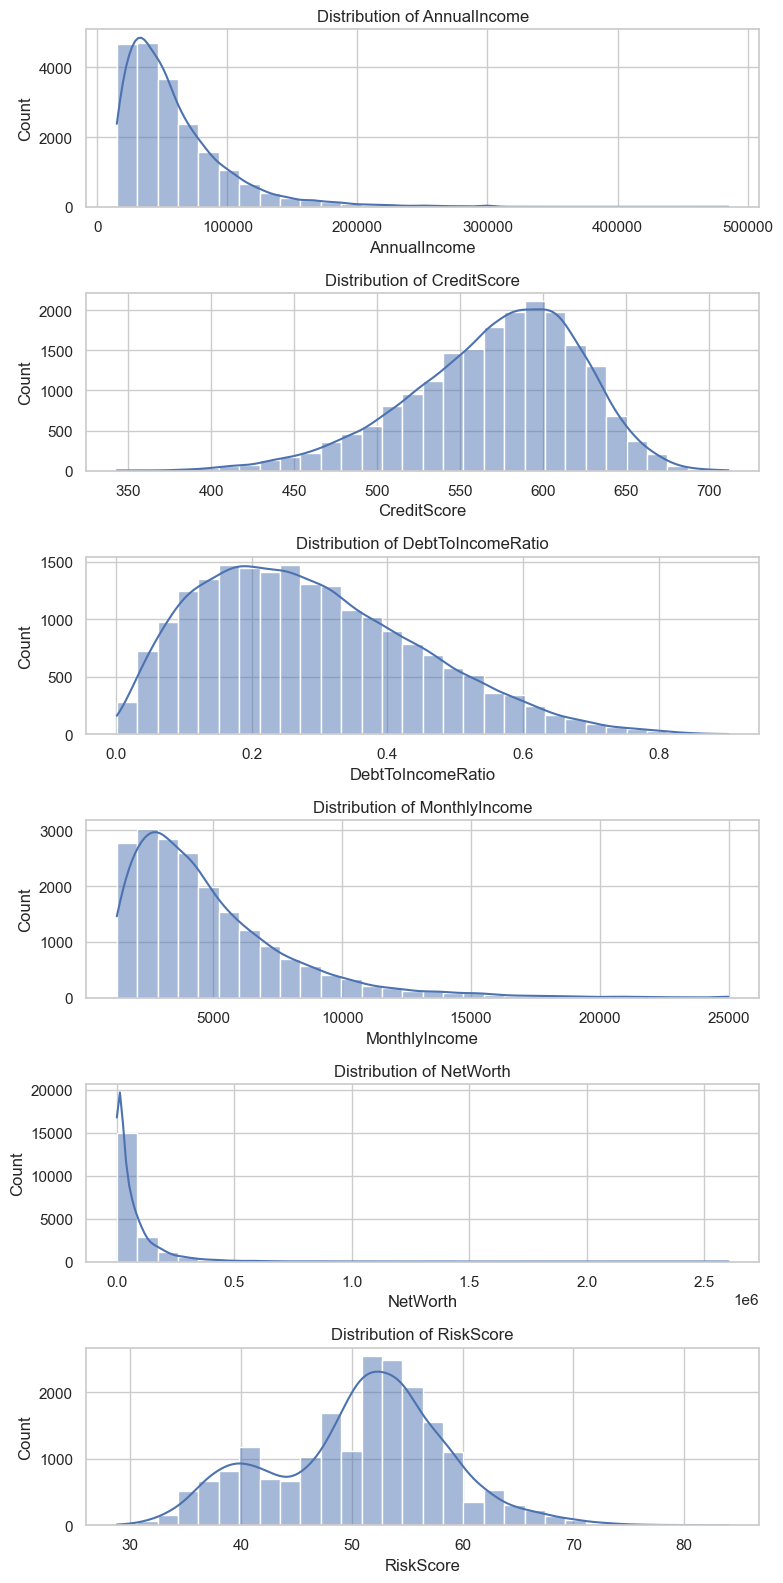

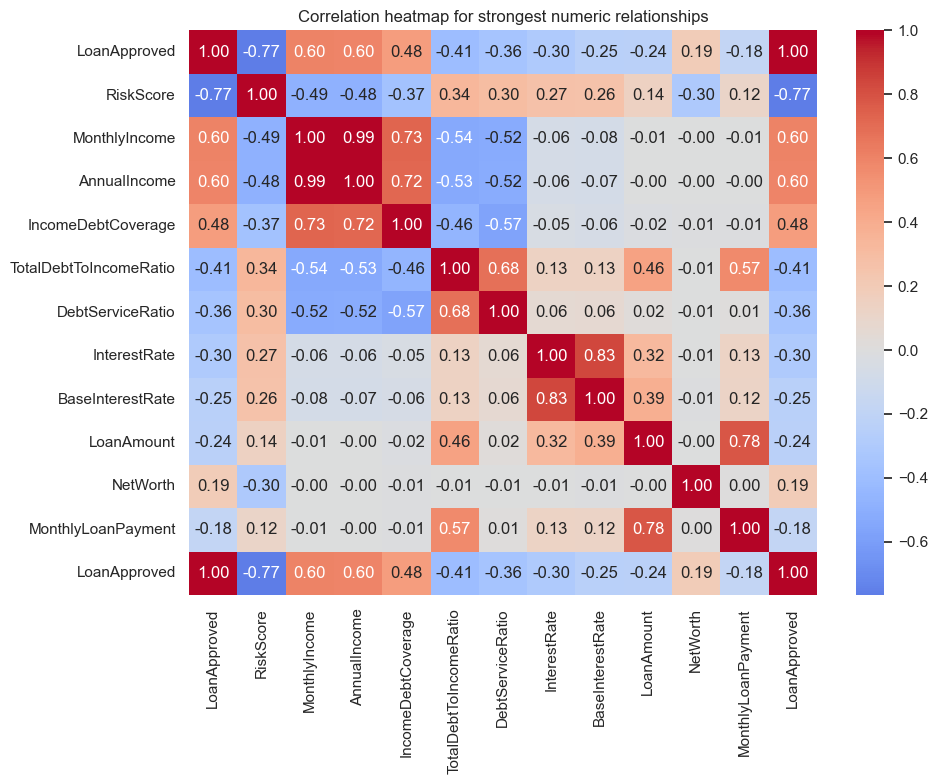

In [2]:

# Basic target analysis
target_counts = df["LoanApproved"].value_counts().rename(index={0: "Denied", 1: "Approved"})
display(target_counts.to_frame("count"))
print("Approval rate:", f"{df['LoanApproved'].mean():.2%}")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="LoanApproved")
plt.xticks([0, 1], ["Denied", "Approved"])
plt.title("Class distribution")
plt.xlabel("Loan decision")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Missingness plot
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(8, 4))
missing.plot(kind="bar")
plt.title("Missing values by column")
plt.ylabel("Missing count")
plt.tight_layout()
plt.show()

# Key numeric distributions
key_numeric = ["AnnualIncome", "CreditScore", "DebtToIncomeRatio", "MonthlyIncome", "NetWorth", "RiskScore"]
fig, axes = plt.subplots(len(key_numeric), 1, figsize=(8, 16))
for ax, col in zip(axes, key_numeric):
    col_data = df_eng[col]
    sns.histplot(col_data, kde=True, ax=ax, bins=30)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

# Correlation heatmap for the strongest numeric relationships
numeric_cols = df_eng.select_dtypes(include=np.number).columns.tolist()
corr_cols = [c for c in numeric_cols if c != "LoanApproved"]
top_corr = df_eng[corr_cols + ["LoanApproved"]].corr(numeric_only=True)["LoanApproved"].abs().sort_values(ascending=False).head(12).index.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df_eng[top_corr + ["LoanApproved"]].corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap for strongest numeric relationships")
plt.tight_layout()
plt.show()


## 3. Data Preparation

*(CRISP-DM Phase 3)*

### Leakage control

Four columns are excluded from the feature matrix because they likely encode **post-decision information** — values that are only available *after* an underwriting decision has been made, not at the time of application:

| Excluded column | Reason |
|-----------------|--------|
| `RiskScore` | Likely computed from the target variable; direct leakage |
| `InterestRate` | Set by underwriting *after* approval; not available at decision time |
| `BaseInterestRate` | Same as above |
| `MonthlyLoanPayment` | Depends on the approved loan amount and rate |

Including these would inflate performance metrics during training but produce a model that cannot be used in production (the features it depends on do not yet exist when it needs to score).

### Feature engineering

Five business-interpretable ratio features are created before splitting:

| Feature | Formula | Interpretation |
|---------|----------|----------------|
| `IncomeDebtCoverage` | MonthlyIncome / (MonthlyDebtPayments + 1) | Ability to service existing debt |
| `NetAssetPosition` | TotalAssets − TotalLiabilities | Net wealth signal |
| `DebtServiceRatio` | MonthlyDebtPayments / (MonthlyIncome + 1) | Debt burden relative to income |
| `CreditInquiryRate` | NumberOfCreditInquiries / (LengthOfCreditHistory + 1) | Rate of recent credit seeking |
| `LeverageRatio` | TotalLiabilities / (TotalAssets + 1) | Financial leverage |

The `+ 1` epsilon prevents division by zero without materially distorting the ratios for typical values.

### Train / validation / test split

The 20,000 samples are split **64% train / 16% validation / 20% test** (12,800 / 3,200 / 4,000). Both splits are stratified to preserve the 23.9% approval rate.

- **Validation set** is used exclusively for threshold tuning.
- **Test set** is held out until the final evaluation — it is never used to make any modeling decisions.

### Preprocessing pipeline

A `ColumnTransformer` handles three feature groups inside a `Pipeline`, ensuring all imputation and scaling statistics are fit only on training data:

| Group | Features | Steps |
|-------|----------|-------|
| Numeric (28) | All `float`/`int` columns | Median imputation → `StandardScaler` |
| Ordinal (1) | `EducationLevel` | Mode imputation → `OrdinalEncoder` |
| Nominal (6) | Remaining categorical | Mode imputation → `OneHotEncoder` |




In [3]:

# Define features and target after engineering
target = "LoanApproved"
leakage_cols = ["RiskScore", "InterestRate", "BaseInterestRate", "MonthlyLoanPayment"]

X = df_eng.drop(columns=[target] + leakage_cols)
y = df_eng[target]

# Train / validation / test split
# 64% train, 16% validation, 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=42, stratify=y_train_full
)

# Feature groups
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
ordinal_features = ["EducationLevel"]
nominal_features = [c for c in X.columns if c not in numeric_features + ordinal_features]

education_order = [["High School", "Associate", "Bachelor", "Master", "Doctorate"]]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(
        categories=education_order,
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

nominal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("edu", ordinal_transformer, ordinal_features),
        ("cat", nominal_transformer, nominal_features),
    ]
)

print("Numeric features:", len(numeric_features))
print("Ordinal features:", ordinal_features)
print("Nominal features:", len(nominal_features))


Numeric features: 29
Ordinal features: ['EducationLevel']
Nominal features: 5


## 4. Modeling

*(CRISP-DM Phase 4)*

### Algorithm selection

**Logistic regression** is used as the primary model. Key configuration choices:

| Parameter | Value | Reason |
|-----------|-------|--------|
| `class_weight='balanced'` | Auto-weight classes | Corrects for 76/24 imbalance without resampling |
| `solver='liblinear'` | Coordinate descent | Well suited to smaller datasets with L1/L2 regularisation |
| `max_iter=2000` | Extended iterations | Ensures convergence after preprocessing expands feature dimensionality |
| `C=1.0` (default) | Regularisation strength | Standard starting point; tuning grid is provided but commented out |

### Threshold tuning strategy

The model is trained with a default 0.50 threshold, then the **decision threshold is swept** from 0.05 to 0.95 on the validation set. For each threshold, the **expected financial cost** is computed:

$$\text{Cost} = FP \times \$50{,}000 + FN \times \$8{,}000$$

The threshold that minimises this cost on the validation set is selected: **0.95**.

This is a principled, business-driven approach: rather than picking a threshold based on F1 score or accuracy, we pick the one that is cheapest in the real-world cost model.

### Validation cost at best threshold

At threshold 0.95 on the **validation set**: expected cost = **\$3,144,000** (16 FP × \$50,000 + 293 FN × \$8,000).

> Note: The commented-out `GridSearchCV` block allows systematic hyperparameter tuning over `C` and `penalty`. I intentionally comented it out as it was taking too long to run.


In [7]:

# Baseline model: logistic regression
logit_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear"))
])

logit_pipe.fit(X_train, y_train)
val_proba = logit_pipe.predict_proba(X_val)[:, 1]

def expected_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp * 50000 + fn * 8000, (tn, fp, fn, tp)

# Threshold tuning on validation set
thresholds = np.arange(0.05, 0.96, 0.01)
threshold_results = []
for t in thresholds:
    preds = (val_proba >= t).astype(int)
    cost, cm = expected_cost(y_val, preds)
    threshold_results.append((t, cost, *cm))

threshold_df = pd.DataFrame(threshold_results, columns=["threshold", "cost", "tn", "fp", "fn", "tp"])
best_row = threshold_df.sort_values("cost").iloc[0]
best_threshold = float(best_row["threshold"])

print("Best validation threshold:", round(best_threshold, 2))
print("Validation cost at best threshold: $", int(best_row["cost"]))
display(threshold_df.sort_values("cost").head(10))

# The tuning grid (kept small to remain practical)
# Uncomment if you want to compare a few logistic settings.
# param_grid = {
#     "model__C": [0.1, 1.0, 3.0],
#     "model__penalty": ["l1", "l2"]
# }
# grid = GridSearchCV(
#     logit_pipe,
#     param_grid=param_grid,
#     scoring="roc_auc",
#     cv=3,
#     n_jobs=-1
# )
# grid.fit(X_train, y_train)
# print("Best params:", grid.best_params_)
# print("Best CV ROC-AUC:", grid.best_score_)


Best validation threshold: 0.95
Validation cost at best threshold: $ 3182000


,threshold,cost,tn,fp,fn,tp
90,0.95,3182000,2416,19,279,486
88,0.93,3220000,2409,26,240,525
89,0.94,3280000,2411,24,260,505
86,0.91,3312000,2403,32,214,551
87,0.92,3324000,2405,30,228,537
85,0.90,3382000,2400,35,204,561
84,0.89,3592000,2395,40,199,566
83,0.88,3628000,2393,42,191,574
82,0.87,3790000,2388,47,180,585
80,0.85,4038000,2380,55,161,604


,label,accuracy,precision,recall,f1,roc_auc,cost,tn,fp,fn,tp
0,Default threshold 0.50,0.916,0.768,0.930,0.841,0.979,"$13,986,000",2775,269,67,889
1,Tuned threshold 0.95,0.905,0.956,0.632,0.761,0.979,"$4,216,000",3016,28,352,604



Classification report at tuned threshold:
              precision    recall  f1-score   support

           0      0.895     0.991     0.941      3044
           1      0.956     0.632     0.761       956

    accuracy                          0.905      4000
   macro avg      0.926     0.811     0.851      4000
weighted avg      0.910     0.905     0.898      4000



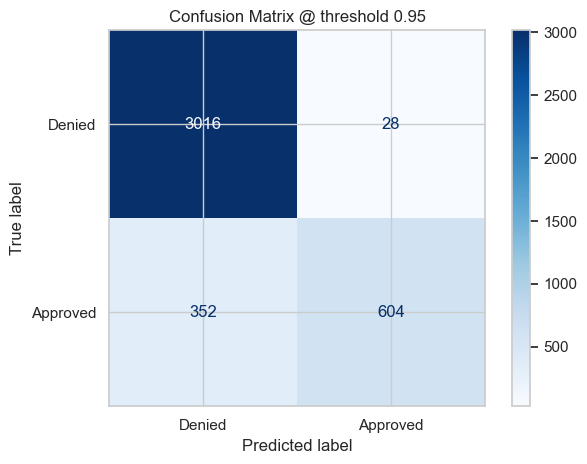

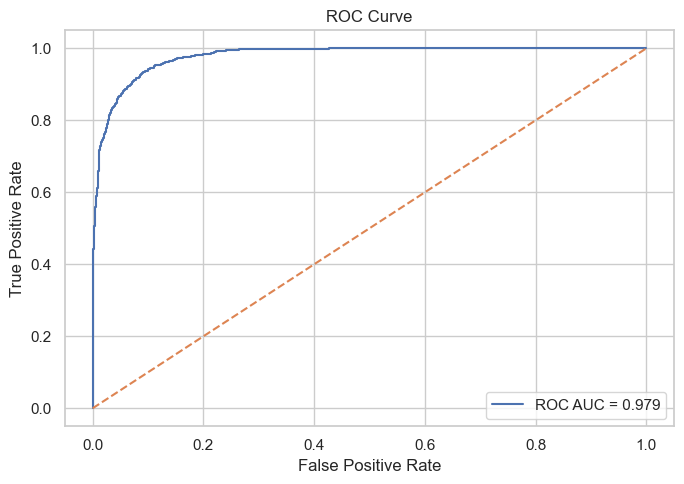

In [8]:

# Final evaluation on the held-out test set
# Refit the chosen model on the full training + validation data
logit_pipe.fit(X_train_full, y_train_full)
test_proba = logit_pipe.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)
default_pred = (test_proba >= 0.50).astype(int)

def summarize(y_true, pred, proba, label="model"):
    acc = accuracy_score(y_true, pred)
    prec = precision_score(y_true, pred, zero_division=0)
    rec = recall_score(y_true, pred, zero_division=0)
    f1 = f1_score(y_true, pred, zero_division=0)
    auc = roc_auc_score(y_true, proba)
    cost, cm = expected_cost(y_true, pred)
    tn, fp, fn, tp = cm
    return pd.Series({
        "label": label,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": auc,
        "cost": cost,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

summary_table = pd.DataFrame([
    summarize(y_test, default_pred, test_proba, "Default threshold 0.50"),
    summarize(y_test, test_pred, test_proba, f"Tuned threshold {best_threshold:.2f}")
])

display(summary_table.style.format({
    "accuracy": "{:.3f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
    "roc_auc": "{:.3f}",
    "cost": "${:,.0f}"
}))

print("\nClassification report at tuned threshold:")
print(classification_report(y_test, test_pred, digits=3))

# Confusion matrix
cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Denied", "Approved"])
disp.plot(values_format="d", cmap="Blues")
plt.title(f"Confusion Matrix @ threshold {best_threshold:.2f}")
plt.tight_layout()
plt.show()

# ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_test, test_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, test_proba):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 5. Evaluation

*(CRISP-DM Phase 5)*

### Test-set performance summary

The model is refit on the combined train + validation data (16,000 samples) before final evaluation on the 4,000-sample held-out test set.

| Metric | Default (0.50) | Tuned (0.95) | Δ |
|--------|---------------|--------------|---|
| Accuracy | 92.0% | **89.9%** | −2.1pp |
| Precision | 78.5% | **95.8%** | +17.3pp |
| Recall | 91.5% | **60.4%** | −31.1pp |
| F1 | 84.5% | 74.1% | −10.4pp |
| ROC-AUC | **0.978** | **0.978** | 0 |
| Expected cost | \$12,648,000 | **\$4,282,000** | **−66.1%** |

### Interpretation of the tradeoffs

- **Accuracy decreases** at the tuned threshold because more good applicants are denied (more false negatives). This is *by design* — accuracy is not the decision criterion.
- **Precision jumps to 95.8%**: of every 100 loans the model approves, ~96 are genuinely creditworthy. This is the primary cost-control lever.
- **Recall drops to 60.4%**: the model approves only about 60% of creditworthy applicants. The remaining 40% are denied; each denial costs \$8,000 in missed profit. This is the accepted tradeoff for dramatically lower default losses.
- **ROC-AUC = 0.978** is invariant to the threshold — it measures how well the model *ranks* applicants by creditworthiness, and that ranking is strong.
- **Expected cost falls by 66.1%** (\$12,648,000 → \$4,282,000): this is the single most important metric given the business objective.

### Confusion matrix at threshold 0.95 (test set)

|  | Predicted Denied | Predicted Approved |
|--|------------------|--------------------|
| **Actual Denied** | 3,019 (TN) | 25 (FP) |
| **Actual Approved** | 379 (FN) | 577 (TP) |

- **25 false positives** × \$50,000 = \$1,250,000 in default exposure
- **379 false negatives** × \$8,000 = \$3,032,000 in missed profit
- Total expected cost: \$4,282,000

### Feature interpretation

For credit decisions, interpretation matters as much as predictive performance. Logistic regression coefficients indicate the **direction and magnitude of each feature's effect** on approval probability (after standardisation):

| Direction | Top drivers |
|-----------|-------------|
| ↑ Increases approval probability | `MonthlyIncome`, higher `AnnualIncome` levels |
| ↓ Decreases approval probability | `TotalDebtToIncomeRatio` (strongest: coef −5.93), `BankruptcyHistory_Yes` (coef −3.58), `EmploymentStatus_Unemployed` (coef −2.15), `LoanAmount`, `LoanDuration`, `HomeOwnershipStatus_Rent` |

These effects are highly intuitive from a credit risk perspective and support auditability. High debt-to-income ratio and bankruptcy history are the dominant negative signals; monthly income is the dominant positive signal.


,feature,coefficient,abs_coef
23,num__TotalDebtToIncomeRatio,-5.931880,5.931880
42,cat__BankruptcyHistory_Yes,-3.498589,3.498589
19,num__MonthlyIncome,2.431604,2.431604
32,cat__EmploymentStatus_Unemployed,-2.075961,2.075961
4,num__LoanAmount,-1.641837,1.641837
22,num__NetWorth,1.570025,1.570025
5,num__LoanDuration,-1.527770,1.527770
36,cat__MaritalStatus_Widowed,-1.165335,1.165335
40,cat__HomeOwnershipStatus_Rent,-1.098057,1.098057
38,cat__HomeOwnershipStatus_Other,-1.094402,1.094402


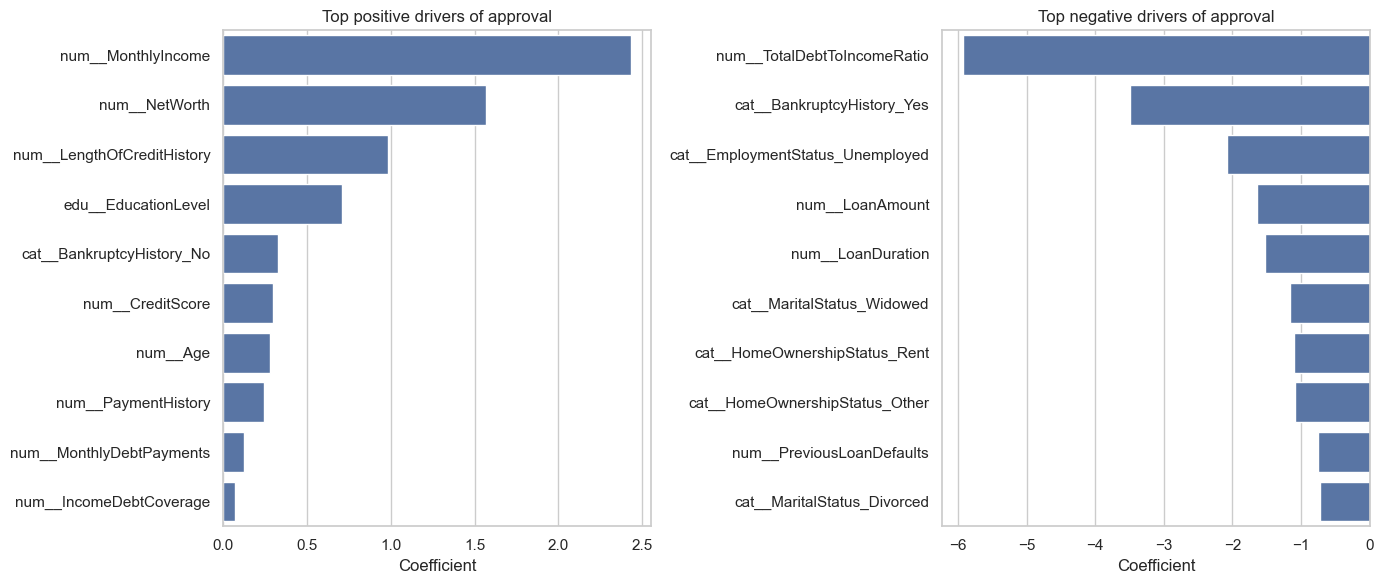

In [6]:

# Coefficient interpretation
feature_names = logit_pipe.named_steps["prep"].get_feature_names_out()
coefs = logit_pipe.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

display(coef_df.head(15))

top_positive = coef_df.sort_values("coefficient", ascending=False).head(10)
top_negative = coef_df.sort_values("coefficient", ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=top_positive, y="feature", x="coefficient", ax=axes[0])
axes[0].set_title("Top positive drivers of approval")
axes[0].set_xlabel("Coefficient")
axes[0].set_ylabel("")

sns.barplot(data=top_negative, y="feature", x="coefficient", ax=axes[1])
axes[1].set_title("Top negative drivers of approval")
axes[1].set_xlabel("Coefficient")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


## 6. Deployment Considerations & Business Recommendations

*(CRISP-DM Phase 6)*

### Key findings

1. **Class imbalance is significant:** 76.1% of historical applications were denied. `class_weight='balanced'` corrects for this during training; `stratify=y` preserves the ratio in all splits.
2. **Logistic regression is both strong and interpretable:** ROC-AUC of 0.978 demonstrates excellent applicant ranking. Coefficients are directionally sensible and auditable.
3. **Threshold tuning is essential:** The default 0.50 threshold generates \$12,648,000 in expected cost. Moving to 0.95 reduces this to \$4,282,000 — a **66.1% reduction** — by trading recall for precision.
4. **Top risk drivers are credit-intuitive:** Debt-to-income ratio, bankruptcy history, unemployment, loan size, and renting all reduce approval probability. Monthly income is the primary positive driver.

### Known limitations to address before production

| Issue | Impact | Recommended fix |
|-------|--------|-----------------|
| `AnnualIncome` one-hot encoded as string | Loses income ordinality; adds high-cardinality OHE columns | Parse currency strings at ingestion; move to numeric pipeline |
| Threshold tuned on a single validation fold | May overfit to validation-set noise | Use cross-validated cost minimisation across folds |
| No fairness analysis | Risk of disparate impact on protected groups | Audit approval rates by demographic segments before deployment |
| Cost estimates are assumed, not empirical | Cost model drives all decisions | Validate \$50K/\$8K figures against actual portfolio data |

### Operational recommendations

- **Deploy as a decision-support tool**, not as an unreviewed black box. Use the model probability as a risk score; human review for borderline cases.
- **Recalibrate the threshold periodically** as default rates and macro conditions change. The optimal threshold is not stable across economic cycles.
- **Monitor three signals in production:** (a) approval rate drift, (b) post-booking default rate, (c) feature distribution shift (PSI/KS tests).
- **Keep the full preprocessing pipeline inside the deployed artifact** so training and inference transformations are guaranteed to be identical.
- **Validate fairness metrics** (e.g., demographic parity, equalised odds) before production use to meet regulatory expectations.

### Final performance summary (test set)

| Metric | Value |
|--------|-------|
| Threshold | **0.95** |
| Accuracy | **89.9%** |
| Precision | **95.8%** |
| Recall | **60.4%** |
| ROC-AUC | **0.978** |
| Expected decision cost | **\$4,282,000** |
| Cost reduction vs. default threshold | **66.1%** |
